We start by showing a simple example of a logistic regression. An iterative optimization method is performed in order to minimize the binary cross-entropy loss function

$$
L=\frac{1}{N}\sum_{i=1}^N [ -y_i \log (p(y_i)) - (1-y_i) \log (1-p(y_i))]
$$,

where y_i are binary outputs (0 or 1). The probability is modeled as a sigmoid function

$$
p(y)=\frac{1}{1+e^{-(\alpha y + \beta)}}
$$

In [ ]:
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ztest

In [2]:
#Reshaped for Logistic function.
X = np.array([3.78, 2.44, 2.09, 0.14, 1.72, 1.65, 4.92, 4.37, 4.96, 4.52, 3.69, 5.88]).reshape(-1,1)
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

logr = linear_model.LogisticRegression()
logr.fit(X,y)

#predict if tumor is cancerous where the size is 3.46mm:
predicted = logr.predict(np.array([3.46]).reshape(-1,1))
print(predicted) 

[0]


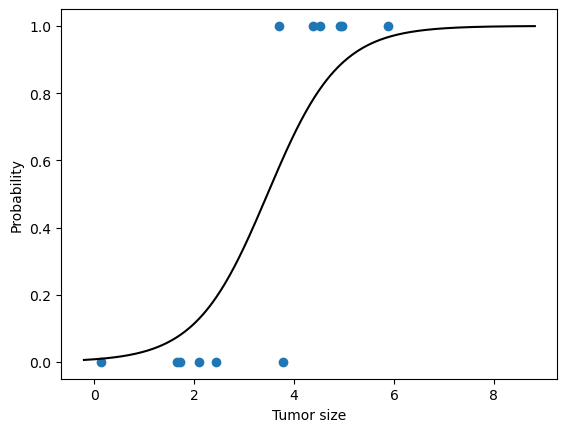

In [5]:
plt.scatter(X, y)

vals = np.linspace(-1.5*X.min(), 1.5*X.max(), 400).reshape(-1,1)

# Evaluate the fitted logistic function
probs = logr.predict_proba(vals)[:,1]

plt.plot(vals, probs, 'k')

plt.xlabel("Tumor size")
plt.ylabel("Probability")
plt.show()

In [6]:
print(logr.coef_)
print(logr.intercept_)

[[1.39514829]]
[-4.83687979]


Quick review of statistical tests.

**Z-test**: Let's suppose we have a sample $S$ of size $n$ from a random variable $X$ with approximately a normal distribution, and we want to determine whether it is equal to some reference value $\mu_0$. Then, we compute the Z-score of $\mu_0$ in this sample:

$$Z = \frac{\langle X \rangle _S-\mu_0}{\Delta X_S/\sqrt{n}},$$

and the so-called p-value. Now we formulate our **null hypothesis** (the opposite of the fact we want to assert):

Two-tailed: THE MEASSURED VARIABLE IS DIFFERENT FROM $\mu_0$ WITH A SIGNIFICANCE LEVEL OF $\alpha$.
The p-value is  2(1-CDF(Z)).

Right-tailed: THE SAMPLE IS GREATER THAN $\mu_0$ WITH A SIGNIFICANCE LEVEL OF $\alpha$.
The p-value is 1-CDF(Z).

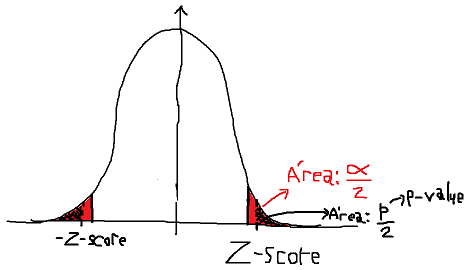

If p > $\alpha$ (or $Z$ greater than the critical value), the null hypothesis is accepted.

In [6]:
alpha = 0.05
sample = np.random.uniform(-1,1, 50)
ztest_score, pval = ztest(sample,value=0.1,alternative='larger')

if(pval>alpha):
     print('Null hypothesis is accepted!')
else:
    print('Null hypothesis is rejected. \nAlternate hypothesis is accepted!')   

Null hypothesis is accepted!


In [8]:
print(np.mean(sample), np.std(sample)/np.sqrt(len(sample)))
print(ztest_score, pval)

0.049336789076672785 0.07803296120019715
-0.6427286524744873 0.7397999071248403
